In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Rescaling, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.nn import softmax

In [5]:
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import RandomZoom, RandomFlip, RandomRotation
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow import expand_dims

In [6]:
data_path = '/content/drive/My Drive/DATA/cell_images'

In [7]:
class_names = os.listdir(data_path)
class_names

['Parasitized', 'Uninfected']

In [8]:
len(os.listdir(data_path + '/' + class_names[0]))

13779

In [9]:
len(os.listdir(data_path + '/' + class_names[1]))

13779

In [10]:
parasitized_cell = data_path + '/' + class_names[0] + '/' + os.listdir(data_path + '/' + class_names[0] + '/')[0]

In [11]:
parasitized_cell_img = imread(parasitized_cell)

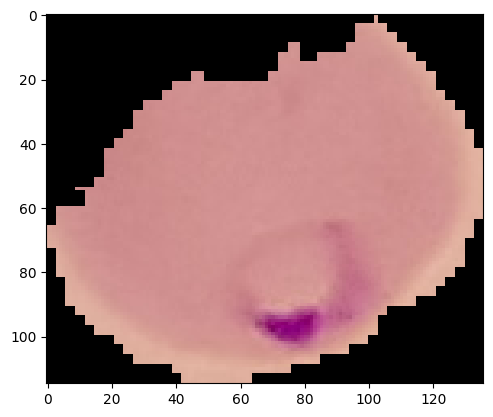

In [12]:
plt.imshow(parasitized_cell_img);

In [13]:
parasitized_cell_img.shape

(115, 136, 3)

In [14]:
uninfected_cell = data_path + '/' + class_names[1] + '/' + os.listdir(data_path + '/' + class_names[1] + '/')[0]

In [15]:
uninfected_cell_img = imread(uninfected_cell)

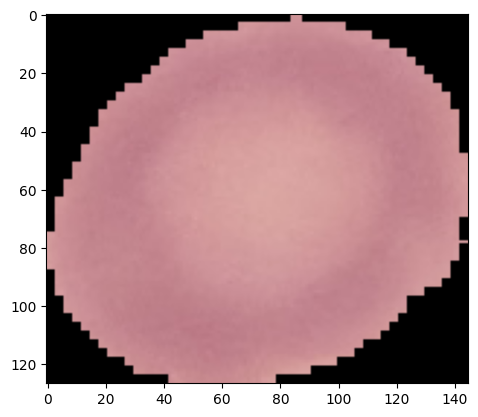

In [16]:
plt.imshow(uninfected_cell_img);

In [17]:
uninfected_cell_img.shape

(127, 145, 3)

In [18]:
'''dim1 = []
dim2 = []
for image_filename in os.listdir(data_path + '/' + class_names[0]):

    img = imread(data_path + '/' + class_names[0] + '/' + image_filename)
    d1,d2,colors = img.shape
    dim1.append(d1)
    dim2.append(d2)'''

"dim1 = []\ndim2 = []\nfor image_filename in os.listdir(data_path + '/' + class_names[0]):\n\n    img = imread(data_path + '/' + class_names[0] + '/' + image_filename)\n    d1,d2,colors = img.shape\n    dim1.append(d1)\n    dim2.append(d2)"

In [19]:
#sns.jointplot(x=dim1,y=dim2);

In [20]:
#np.mean(dim1)

In [21]:
#np.mean(dim2)

In [22]:
img_height = 134
img_width = 134
colors = 3

In [23]:
batch_size = 32

In [24]:
train_ds = image_dataset_from_directory(
    directory=data_path,
    batch_size=batch_size,
    image_size=(img_height,img_width),
    seed=101,
    validation_split=0.3,
    subset='training'
)

Found 27558 files belonging to 2 classes.
Using 19291 files for training.


In [25]:
val_ds = image_dataset_from_directory(
    directory=data_path,
    batch_size=batch_size,
    image_size=(img_height,img_width),
    seed=101,
    validation_split=0.3,
    subset='validation'
)

Found 27558 files belonging to 2 classes.
Using 8267 files for validation.


In [26]:
data_augmentation = Sequential([
    RandomFlip('horizontal_and_vertical', input_shape=(img_height,img_width,colors)),
    RandomRotation(0.2),
    RandomZoom(0.1)
])

In [27]:
parasitized_cell_img.max()

0.9019608

In [28]:
model = Sequential()

model.add(data_augmentation)
# model.add(Rescaling(1.0/255))
model.add(Conv2D(filters=16, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D())
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D())
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D())
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=2))

In [29]:
model.compile(loss=SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

In [30]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 134, 134, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 134, 134, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 67, 67, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 67, 67, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 33, 33, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 33, 33, 64)       

In [31]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

In [ ]:
model.fit(train_ds, epochs=10, callbacks=[early_stop], validation_data=val_ds)

Epoch 1/10
  2/603 [..............................] - ETA: 48:03 - loss: 121.2036 - accuracy: 0.5781 

In [ ]:
losses = pd.DataFrame(model.history.history)

In [ ]:
losses[['accuracy','val_accuracy']].plot();

In [ ]:
losses[['loss','val_loss']].plot();

In [ ]:
img = load_img(parasitized_cell, target_size=(img_height,img_width))
img_array = img_to_array(img)
img_array = expand_dims(img_array, 0)

In [ ]:
prediction = softmax(model.predict(img_array))

In [ ]:
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

In [ ]:
print(f'This image belongs to {class_names[predicted_class]} with a {np.floor(confidence*1e4)/100}% of condifence.')

In [ ]:
model.save('/content/drive/My Drive/DATA/malaria_model.keras')